## 1. Import Libraries
Mengimpor semua library yang akan digunakan sepanjang pipeline ini.

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Database ──────────────────────────────────────────────────────────────────
from sqlalchemy import create_engine

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# ── Modeling ──────────────────────────────────────────────────────────────────
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression

# ── Evaluasi ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score
)

# ── Explainability ────────────────────────────────────────────────────────────
import shap

print("Semua library berhasil diimport.")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   lightgbm   : {lgb.__version__}")
print(f"   shap       : {shap.__version__}")

Semua library berhasil diimport.
   pandas     : 3.0.3
   numpy      : 2.4.6
   lightgbm   : 4.6.0
   shap       : 0.52.0


## 2. Koneksi Database & Data Extraction
Connect ke PostgreSQL dan menarik semua data dari master_credit_risk_view.

In [22]:
# ── Konfigurasi koneksi ───────────────────────────────────────────────────────
DB_CONFIG = {
    "user"    : "postgres",
    "host"    : "localhost",
    "port"    : "5433",
    "database": "home_credit_risk"
}

from dotenv import load_dotenv
import os

load_dotenv('../.env')
DB_PASSWORD = os.environ.get("PG_PASSWORD")
print("Password loaded:", "BERHASIL" if DB_PASSWORD else "GAGAL")

CONNECTION_STRING = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_PASSWORD}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

engine = create_engine(CONNECTION_STRING)

# ── Query & Load ──────────────────────────────────────────────────────────────
QUERY = "SELECT * FROM master_credit_risk_view;"

print(" Menarik data dari master_credit_risk_view...")
df = pd.read_sql(QUERY, engine)
print(f" Data berhasil dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()

Password loaded: BERHASIL
 Menarik data dari master_credit_risk_view...
 Data berhasil dimuat: 307,511 baris x 28 kolom


,sk_id_curr,is_default,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,name_education_type,...,ext_source_1,ext_source_2,ext_source_3,age_years,years_employed,avg_days_credit_bureau,total_bureau_loans,total_active_bureau_loans,total_prev_apps,total_refused_apps
0,100343,0,M,Y,Y,0,315000.0,90000.0,4504.5,Secondary / secondary special,...,0.259823,0.581980,0.537070,30.0,1.0,921.0,7,2,7,2
1,100348,0,F,N,N,0,135000.0,1223010.0,47983.5,Incomplete higher,...,NaN,0.598658,0.672243,28.0,1.0,1320.0,1,1,0,0
2,100350,0,F,N,Y,0,112500.0,481495.5,31833.0,Secondary / secondary special,...,NaN,0.501308,0.600658,62.0,1001.0,708.0,9,3,10,2
3,100354,0,F,N,Y,1,112500.0,135000.0,6750.0,Secondary / secondary special,...,NaN,0.042010,NaN,25.0,7.0,0.0,0,0,4,0
4,100356,0,F,N,Y,0,180000.0,188685.0,14944.5,Secondary / secondary special,...,NaN,0.561955,0.544235,58.0,1.0,512.0,4,1,3,1


## 3. Exploratory Data Analysis (Quick Check)
Sebelum preprocessing, kita lihat dulu kondisi data — tipe data, missing values, dan distribusi target variable.

In [23]:
print("=" * 55)
print("  INFORMASI DASAR DATASET")
print("=" * 55)
df.info()

  INFORMASI DASAR DATASET
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   sk_id_curr                  307511 non-null  int64  
 1   is_default                  307511 non-null  int64  
 2   code_gender                 307511 non-null  str    
 3   flag_own_car                307511 non-null  str    
 4   flag_own_realty             307511 non-null  str    
 5   cnt_children                307511 non-null  int64  
 6   amt_income_total            307511 non-null  float64
 7   amt_credit                  307511 non-null  float64
 8   amt_annuity                 307499 non-null  float64
 9   name_education_type         307511 non-null  str    
 10  name_family_status          307511 non-null  str    
 11  name_income_type            307511 non-null  str    
 12  name_contract_type          307511 non-null  str    
 13 

In [24]:
print("\n── Missing Values ──────────────────────────────────────")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_report if not missing_report.empty else "Tidak ada missing values.")


── Missing Values ──────────────────────────────────────
                 Missing Count  Missing %
ext_source_1            173378      56.38
ext_source_3             60965      19.83
ext_source_2               660       0.21
amt_annuity                 12       0.00
cnt_fam_members              2       0.00


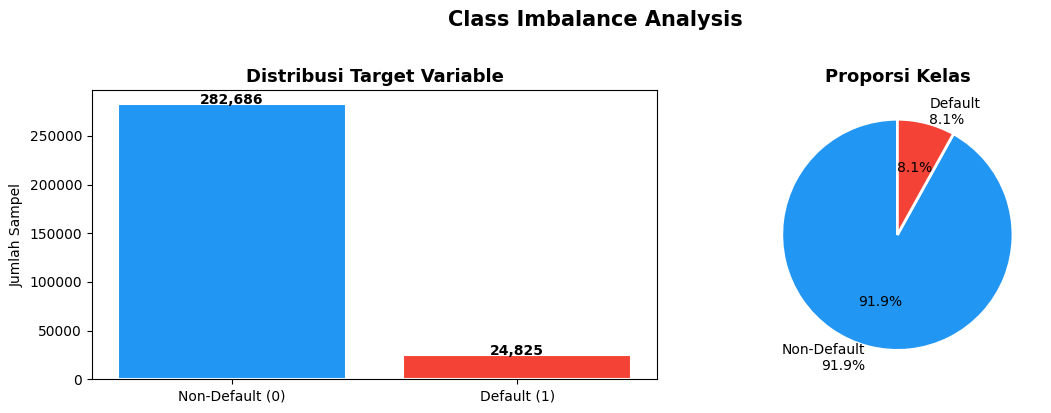


Imbalance Ratio  → 1 : 11.4
Default Rate     → 8.07%


In [25]:
# Distribusi Target Variable (Class Imbalance Check)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['is_default'].value_counts()
target_pct    = df['is_default'].value_counts(normalize=True) * 100

# Bar chart
axes[0].bar(
    ['Non-Default (0)', 'Default (1)'],
    target_counts.values,
    color=['#2196F3', '#F44336'],
    edgecolor='white', linewidth=1.5
)
axes[0].set_title('Distribusi Target Variable', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=[f'Non-Default\n{target_pct[0]:.1f}%', f'Default\n{target_pct[1]:.1f}%'],
    colors=['#2196F3', '#F44336'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Kelas', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nImbalance Ratio  → 1 : {target_counts[0]/target_counts[1]:.1f}")
print(f"Default Rate     → {target_pct[1]:.2f}%")

## 4. Data Preprocessing

### 4.1 — Handle Anomali years_employed
Nilai 365243 di days_employed adalah placeholder untuk pensiunan/unemployed. Setelah dikonversi ke tahun di SQL, nilainya menjadi ~1000. Replace ke NaN agar tidak merusak distribusi fitur.


In [39]:
ANOMALY_THRESHOLD = 60  # Asumsi wajar: tidak ada yang bekerja > 60 tahun

anomaly_count = (df['years_employed'] > ANOMALY_THRESHOLD).sum()
print(f"Jumlah baris anomali years_employed (> {ANOMALY_THRESHOLD} tahun): {anomaly_count:,}")

df['years_employed'] = df['years_employed'].where(
    df['years_employed'] <= ANOMALY_THRESHOLD, other=np.nan
)

# Tambah flag biner sebagai fitur tambahan — pensiunan/unemployed bisa jadi signal risiko
df['flag_unemployed'] = anomaly_count  # akan di-overwrite baris berikutnya
df['flag_unemployed'] = (df['years_employed'].isna()).astype(int)

print(f"✅ Anomali berhasil di-handle. Flag 'flag_unemployed' ditambahkan.")

Jumlah baris anomali years_employed (> 60 tahun): 0
✅ Anomali berhasil di-handle. Flag 'flag_unemployed' ditambahkan.


### 4.2 — Pisahkan Fitur & Target

In [40]:
# Drop kolom ID (tidak relevan sebagai fitur prediktif)
df_model = df.drop(columns=['sk_id_curr'])

# Feature engineering tambahan
df_model['credit_income_ratio']    = df_model['amt_credit'] / (df_model['amt_income_total'] + 1)
df_model['annuity_income_ratio']   = df_model['amt_annuity'] / (df_model['amt_income_total'] + 1)
df_model['credit_annuity_ratio']   = df_model['amt_credit'] / (df_model['amt_annuity'] + 1)
df_model['refused_rate']           = df_model['total_refused_apps'] / (df_model['total_prev_apps'] + 1)
df_model['active_bureau_rate']     = df_model['total_active_bureau_loans'] / (df_model['total_bureau_loans'] + 1)
df_model['ext_source_mean']        = df_model[['ext_source_1','ext_source_2','ext_source_3']].mean(axis=1)
df_model['ext_source_min']         = df_model[['ext_source_1','ext_source_2','ext_source_3']].min(axis=1)

TARGET   = 'is_default'
FEATURES = [col for col in df_model.columns if col != TARGET]

X = df_model[FEATURES].copy()
y = df_model[TARGET].copy()

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"Fitur   : {FEATURES}")

Shape X : (307511, 34)
Shape y : (307511,)
Fitur   : ['code_gender', 'flag_own_car', 'flag_own_realty', 'cnt_children', 'amt_income_total', 'amt_credit', 'amt_annuity', 'name_education_type', 'name_family_status', 'name_income_type', 'name_contract_type', 'region_population_relative', 'flag_work_phone', 'flag_phone', 'flag_email', 'cnt_fam_members', 'ext_source_1', 'ext_source_2', 'ext_source_3', 'age_years', 'years_employed', 'avg_days_credit_bureau', 'total_bureau_loans', 'total_active_bureau_loans', 'total_prev_apps', 'total_refused_apps', 'flag_unemployed', 'credit_income_ratio', 'annuity_income_ratio', 'credit_annuity_ratio', 'refused_rate', 'active_bureau_rate', 'ext_source_mean', 'ext_source_min']


### 4.3 — Identifikasi Tipe Kolom

In [41]:
CAT_COLS = X.select_dtypes(include=['object']).columns.tolist()
NUM_COLS = X.select_dtypes(include=['number']).columns.tolist()

print(f"Kolom Kategorikal ({len(CAT_COLS)}) : {CAT_COLS}")
print(f"Kolom Numerikal   ({len(NUM_COLS)}) : {NUM_COLS}")

Kolom Kategorikal (7) : ['code_gender', 'flag_own_car', 'flag_own_realty', 'name_education_type', 'name_family_status', 'name_income_type', 'name_contract_type']
Kolom Numerikal   (27) : ['cnt_children', 'amt_income_total', 'amt_credit', 'amt_annuity', 'region_population_relative', 'flag_work_phone', 'flag_phone', 'flag_email', 'cnt_fam_members', 'ext_source_1', 'ext_source_2', 'ext_source_3', 'age_years', 'years_employed', 'avg_days_credit_bureau', 'total_bureau_loans', 'total_active_bureau_loans', 'total_prev_apps', 'total_refused_apps', 'flag_unemployed', 'credit_income_ratio', 'annuity_income_ratio', 'credit_annuity_ratio', 'refused_rate', 'active_bureau_rate', 'ext_source_mean', 'ext_source_min']


### 4.4 — Encoding Kolom Kategorikal
Gunakan Label Encoding untuk semua kolom kategorikal. LightGBM bisa handle ini dengan baik secara native — tidak perlu One-Hot Encoding yang akan membengkakkan dimensi.

In [42]:
le = LabelEncoder()
label_encoders = {}

for col in CAT_COLS:
    X[col] = X[col].astype(str).fillna('Unknown')
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"  ✅ Encoded: {col}")

print(f"\nTotal kolom setelah encoding: {X.shape[1]}")

  ✅ Encoded: code_gender
  ✅ Encoded: flag_own_car
  ✅ Encoded: flag_own_realty
  ✅ Encoded: name_education_type
  ✅ Encoded: name_family_status
  ✅ Encoded: name_income_type
  ✅ Encoded: name_contract_type

Total kolom setelah encoding: 34


### 4.5 — Imputasi Missing Values
Setelah encoding, imputasi missing values pada kolom numerik (termasuk years_employed yang sudah di-replace ke NaN tadi).

In [43]:
imputer = SimpleImputer(strategy='median')
X[NUM_COLS] = imputer.fit_transform(X[NUM_COLS])

print(f"✅ Imputasi selesai. Missing values tersisa: {X.isnull().sum().sum()}")

✅ Imputasi selesai. Missing values tersisa: 0


## 5. Train-Test Split
Split data dengan stratifikasi untuk menjaga proporsi kelas tetap konsisten di train dan test set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"Train set : {X_train.shape[0]:,} baris  |  Default rate: {y_train.mean():.3f}")
print(f"Test set  : {X_test.shape[0]:,} baris  |  Default rate: {y_test.mean():.3f}")

Train set : 246,008 baris  |  Default rate: 0.081
Test set  : 61,503 baris  |  Default rate: 0.081


## 6. Handle Class Imbalance dengan scale_pos_weight

Dataset ini memiliki imbalance ratio ~1:11 (default vs non-default). 
Daripada SMOTE, kita manfaatkan parameter `scale_pos_weight` bawaan 
LightGBM yang memberi bobot lebih besar ke kelas minoritas saat 
menghitung loss. Pendekatan ini lebih cocok untuk tree-based model 
karena tidak membuat data sintetis yang berpotensi menambah noise, 
dan training lebih efisien karena ukuran data tetap asli (246k bukan 452k).

In [56]:
X_train_np = X_train.values
y_train_np = y_train.values
X_test_np  = X_test.values
y_test_np  = y_test.values

neg_count        = (y_train_np == 0).sum()
pos_count        = (y_train_np == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Train shape      : {X_train_np.shape}")
print(f"Imbalance ratio  : 1 : {scale_pos_weight:.2f}")
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

Train shape      : (246008, 34)
Imbalance ratio  : 1 : 11.39
scale_pos_weight : 11.39


## 7. Model Training — LightGBM
LightGBM dipilih karena beberapa alasan kuat untuk kasus ini:

- Sangat efisien di dataset besar (jutaan baris) dengan memory footprint rendah
- Native support untuk imbalanced data via scale_pos_weight
- Performa state-of-the-art untuk tabular data di industri fintech
- Interpretable via SHAP

In [54]:
# ── LightGBM ──────────────────────────────────────────────────────────────────
neg_count        = (y_train_np == 0).sum()
pos_count        = (y_train_np == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 2000,   
    learning_rate     = 0.02,   
    max_depth         = 7,      
    num_leaves        = 63,
    min_child_samples = 50,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    reg_alpha         = 0.1,    
    reg_lambda        = 0.1,    
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

print("\n Training LightGBM...")
lgb_model.fit(
    X_train_np, y_train_np,
    eval_set  = [(X_test_np, y_test_np)],
    eval_metric = 'auc',
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, min_delta=0.0001, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print(f"\n✅ Training selesai. Best iteration: {lgb_model.best_iteration_}")

scale_pos_weight : 11.39

 Training LightGBM...
Training until validation scores don't improve for 50 rounds
Using 0.0001 as min_delta for all metrics.
[50]	valid_0's auc: 0.741756	valid_0's binary_logloss: 0.255949
[100]	valid_0's auc: 0.748576	valid_0's binary_logloss: 0.250415
[150]	valid_0's auc: 0.753708	valid_0's binary_logloss: 0.248075
[200]	valid_0's auc: 0.757501	valid_0's binary_logloss: 0.246725
[250]	valid_0's auc: 0.759646	valid_0's binary_logloss: 0.246016
[300]	valid_0's auc: 0.760882	valid_0's binary_logloss: 0.245626
[350]	valid_0's auc: 0.761644	valid_0's binary_logloss: 0.245372
[400]	valid_0's auc: 0.762679	valid_0's binary_logloss: 0.245046
[450]	valid_0's auc: 0.762949	valid_0's binary_logloss: 0.244953
[500]	valid_0's auc: 0.76331	valid_0's binary_logloss: 0.244835
Early stopping, best iteration is:
[481]	valid_0's auc: 0.763252	valid_0's binary_logloss: 0.24486

✅ Training selesai. Best iteration: 481


## 8. Model Evaluation
### 8.1 — Prediksi & ROC-AUC

In [65]:
# ── Evaluasi ──────────────────────────────────────────────────────────────────
y_pred_proba = lgb_model.predict_proba(X_test_np)[:, 1]
y_pred       = lgb_model.predict(X_test_np)

roc_auc = roc_auc_score(y_test_np, y_pred_proba)
avg_prc = average_precision_score(y_test_np, y_pred_proba)

print(f"ROC-AUC Score          : {roc_auc:.4f}")
print(f"Average Precision Score: {avg_prc:.4f}")

ROC-AUC Score          : 0.7633
Average Precision Score: 0.2456


### 8.2 — Threshold Tuning
Di credit risk, false negative (defaulter yang tidak terdeteksi) jauh lebih mahal dari false positive. Kita cari threshold optimal yang memaksimalkan F1-score untuk kelas default.

In [66]:
precisions, recalls, thresholds = precision_recall_curve(y_test_np, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

optimal_idx       = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Threshold default (0.5)  → F1 default class: {f1_scores[np.argmin(abs(thresholds - 0.5))]:.4f}")
print(f"Threshold optimal        : {optimal_threshold:.4f}")
print(f"F1 optimal               : {f1_scores[optimal_idx]:.4f}")

# Prediksi ulang dengan threshold optimal
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

Threshold default (0.5)  → F1 default class: 0.0429
Threshold optimal        : 0.1489
F1 optimal               : 0.3116


### 8.3 — Visualisasi Lengkap

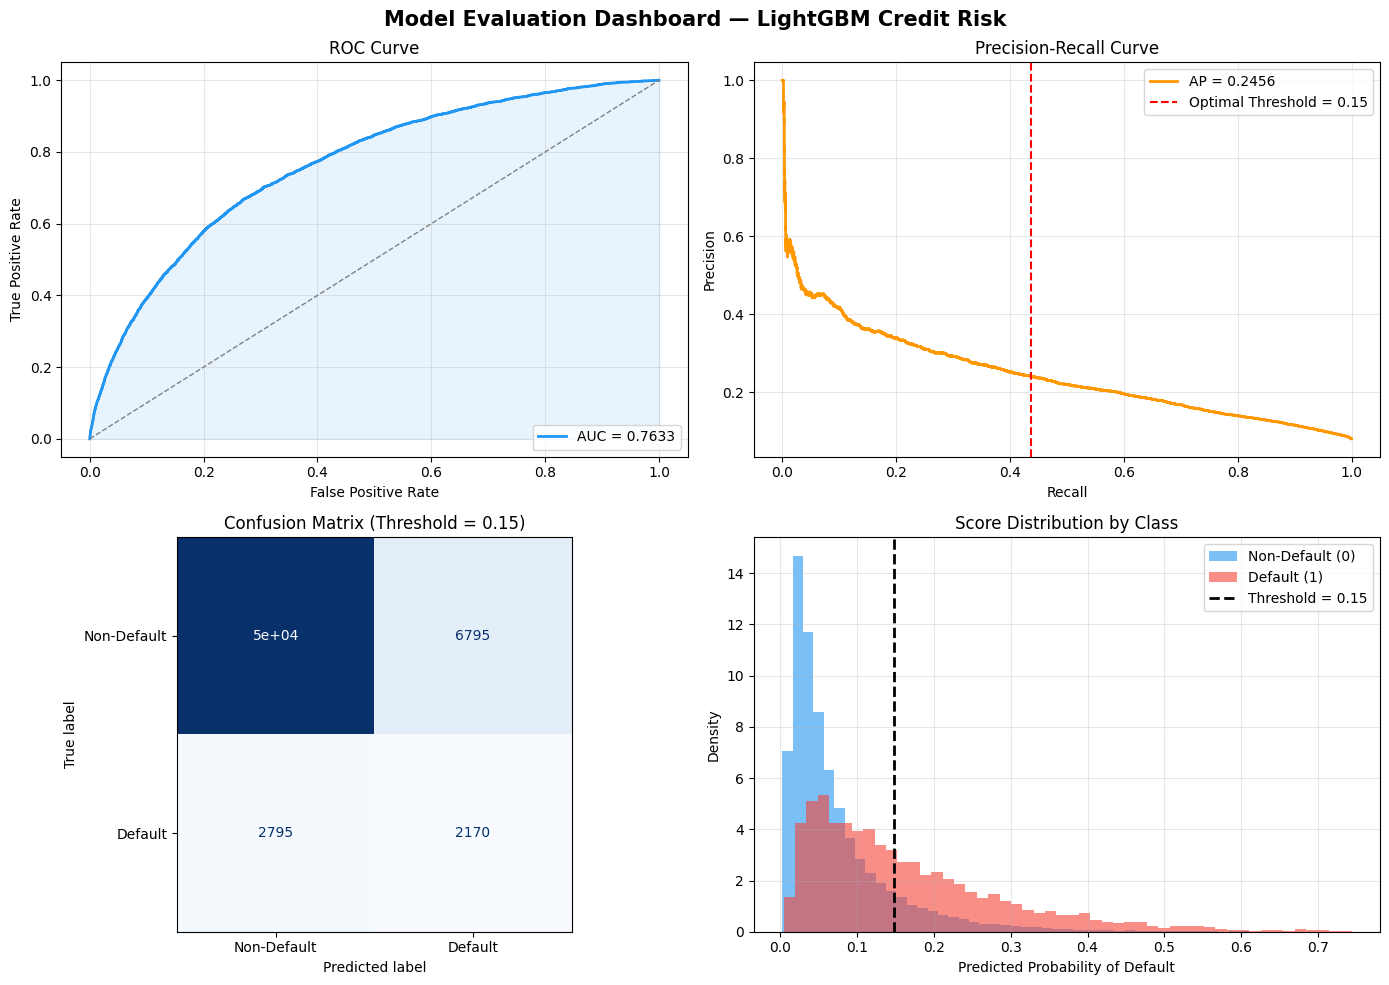

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Evaluation Dashboard — LightGBM Credit Risk', fontsize=15, fontweight='bold')

# ── Plot 1: ROC Curve ─────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test_np, y_pred_proba)
axes[0, 0].plot(fpr, tpr, color='#2196F3', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0, 0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[0, 0].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# ── Plot 2: Precision-Recall Curve ───────────────────────────────────────────
axes[0, 1].plot(recalls, precisions, color='#FF9800', lw=2, label=f'AP = {avg_prc:.4f}')
axes[0, 1].axvline(x=recalls[optimal_idx], color='red', linestyle='--', lw=1.5,
                    label=f'Optimal Threshold = {optimal_threshold:.2f}')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ── Plot 3: Confusion Matrix (default threshold) ──────────────────────────────
cm = confusion_matrix(y_test_np, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])
disp.plot(ax=axes[1, 0], colorbar=False, cmap='Blues')
axes[1, 0].set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})')

# ── Plot 4: Predicted Probability Distribution ───────────────────────────────
axes[1, 1].hist(y_pred_proba[y_test_np == 0], bins=50, alpha=0.6, color='#2196F3',
                label='Non-Default (0)', density=True)
axes[1, 1].hist(y_pred_proba[y_test_np == 1], bins=50, alpha=0.6, color='#F44336',
                label='Default (1)', density=True)
axes[1, 1].axvline(x=optimal_threshold, color='black', linestyle='--', lw=2,
                    label=f'Threshold = {optimal_threshold:.2f}')
axes[1, 1].set_xlabel('Predicted Probability of Default')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Score Distribution by Class')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 — Classification Report 

In [68]:
print("=" * 60)
print("  CLASSIFICATION REPORT (Optimal Threshold)")
print("=" * 60)
print(classification_report(y_test_np, y_pred_optimal, target_names=['Non-Default', 'Default']))

  CLASSIFICATION REPORT (Optimal Threshold)
              precision    recall  f1-score   support

 Non-Default       0.95      0.88      0.91     56538
     Default       0.24      0.44      0.31      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.66      0.61     61503
weighted avg       0.89      0.84      0.86     61503

